In [2]:
import pandas as pd

# Load classification metrics CSV
df = pd.read_csv("classification_report_updated.csv")

print("Shape:", df.shape)
df.head()
print(df.columns)

Shape: (118, 6)
Index(['label', 'precision', 'recall', 'f1_score', 'support', 'train_samples'], dtype='object')


In [5]:
# Define threshold
threshold = 0.6

weak_cwe = df[
    (df["precision"] < threshold) |
    (df["recall"] < threshold) |
    (df["f1_score"] < threshold)
]

print("Weak CWEs count:", len(weak_cwe))
weak_cwe.sort_values("f1_score").head(10)

Weak CWEs count: 48


,label,precision,recall,f1_score,support,train_samples
8,CWE15,0.0,0.0,0.0,152,122
99,CWE676,0.0,0.0,0.0,42,34
95,CWE667,0.0,0.0,0.0,42,34
94,CWE666,0.0,0.0,0.0,186,149
93,CWE665,0.0,0.0,0.0,602,482
92,CWE620,0.0,0.0,0.0,40,32
82,CWE570,0.0,0.0,0.0,30,30
76,CWE534,0.0,0.0,0.0,76,61
72,CWE506,0.0,0.0,0.0,181,202
69,CWE483,0.0,0.0,0.0,44,37


In [6]:
print("Smallest classes:")
df.sort_values("support").head(10)

print("\nLargest classes:")
df.sort_values("support", ascending=False).head(10)

Smallest classes:

Largest classes:


,label,precision,recall,f1_score,support,train_samples
2,CWE122,0.9876,0.9994,0.9934,12700,13051
1,CWE121,0.9997,0.9993,0.9995,12158,11950
110,CWE78,0.9936,1.0000,0.9968,11884,11875
11,CWE190,0.9998,0.9983,0.9990,9178,9825
7,CWE134,0.8962,0.9954,0.9432,7782,7320
12,CWE191,1.0000,0.9984,0.9992,7342,7262
107,CWE762,0.9965,1.0000,0.9982,6802,6939
86,CWE590,1.0000,1.0000,1.0000,5400,5280
37,CWE36,0.9650,1.0000,0.9822,4470,4579
20,CWE23,0.9393,1.0000,0.9687,4470,4579


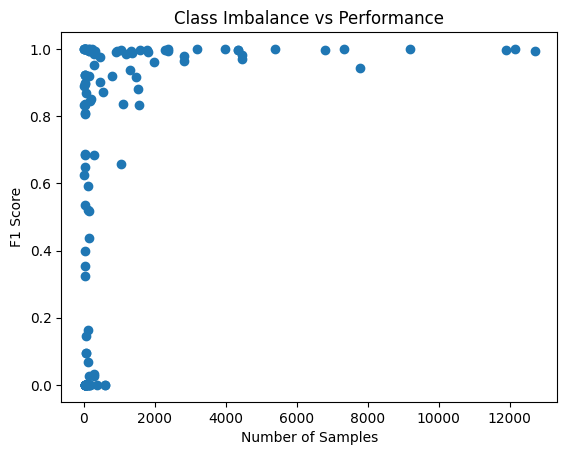

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["support"], df["f1_score"])
plt.xlabel("Number of Samples")
plt.ylabel("F1 Score")
plt.title("Class Imbalance vs Performance")
plt.show()

In [10]:
def classify_failure(row):
    if row["f1_score"] > 0.9:
        return "Stable"
    elif row["recall"] < 0.5:
        return "False Negatives (Missed)"
    elif row["precision"] < 0.5:
        return "False Positives (Over-predict)"
    else:
        return "Unstable"

df["failure_type"] = df.apply(classify_failure, axis=1)

df["failure_type"].value_counts()

failure_type
Stable                            55
False Negatives (Missed)          37
Unstable                          19
False Positives (Over-predict)     7
Name: count, dtype: int64

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(all_labels, all_preds)

cm_df = pd.DataFrame(cm)
print("Confusion matrix shape:", cm_df.shape)
cm_df.head()

In [11]:
def analyze_classification_report(report_dict):
    analysis = {}
    
    for cwe, metrics in report_dict.items():
        if isinstance(metrics, dict) and 'precision' in metrics:
            precision = metrics['precision']
            support = metrics['support']
            
            # Flag potential problem classes
            if precision < 0.7:
                analysis[cwe] = {
                    'precision': precision,
                    'support': support,
                    'issue': 'High false positive rate',
                    'possible_confusions': suggest_confusions(cwe)
                }
            elif precision > 0.95:
                analysis[cwe] = {
                    'precision': precision,
                    'support': support,
                    'issue': 'Well-classified',
                }
    
    return analysis

def suggest_confusions(cwe):
    # Based on CWE characteristics
    confusion_map = {
        'CWE-89': ['CWE-78', 'CWE-90'],  # SQL injection with other injections
        'CWE-79': ['CWE-80', 'CWE-87'],  # XSS with other output issues
        'CWE-22': ['CWE-23', 'CWE-36'],  # Path traversal
        # Add more based on your specific CWEs
    }
    return confusion_map.get(cwe, ['Unknown similar CWE'])

In [13]:
# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create figure with subplots
fig = plt.figure(figsize=(20, 15))

# 1.1 Problematic CWEs by Precision (Top 20 worst)
ax1 = plt.subplot(2, 2, 1)
worst_precision = df.nsmallest(20, 'precision')[['label', 'precision', 'support']]
colors = ['red' if p < 0.5 else 'orange' if p < 0.7 else 'yellow' for p in worst_precision['precision']]
bars = ax1.barh(range(len(worst_precision)), worst_precision['precision'].values, color=colors)
ax1.set_yticks(range(len(worst_precision)))
ax1.set_yticklabels(worst_precision['label'].values)
ax1.set_xlabel('Precision', fontsize=12)
ax1.set_title('Top 20 CWEs with Lowest Precision', fontsize=14, fontweight='bold')
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random guess level')
ax1.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='Acceptable threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels
for i, (bar, p) in enumerate(zip(bars, worst_precision['precision'].values)):
    ax1.text(p + 0.01, bar.get_y() + bar.get_height()/2, f'{p:.3f}', va='center')

# 1.2 Precision vs Support scatter plot
ax2 = plt.subplot(2, 2, 2)
scatter = ax2.scatter(df['support'], df['precision'], 
                      c=df['f1_score'], cmap='RdYlGn', s=50, alpha=0.6)
ax2.set_xlabel('Support (Test Samples)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision vs Support (Color = F1 Score)', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.axhline(y=0.7, color='orange', linestyle='--', alpha=0.5)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=ax2, label='F1 Score')

# Highlight problematic points
problematic = df[df['precision'] < 0.7]
ax2.scatter(problematic['support'], problematic['precision'], 
           color='red', s=100, alpha=0.5, edgecolors='black', linewidth=2, label='Problematic')

# 1.3 Distribution of Precision
ax3 = plt.subplot(2, 2, 3)
df['precision'].hist(bins=30, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Precision', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Distribution of Precision Across CWEs', fontsize=14, fontweight='bold')
ax3.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='Acceptable')
ax3.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
ax3.legend()

# 1.4 Zero Precision CWEs
ax4 = plt.subplot(2, 2, 4)
zero_precision = df[df['precision'] == 0].nsmallest(30, 'support')[['label', 'support']]
if len(zero_precision) > 0:
    colors_zero = plt.cm.Reds(np.linspace(0.3, 0.8, len(zero_precision)))
    bars = ax4.barh(range(len(zero_precision)), zero_precision['support'].values, color=colors_zero)
    ax4.set_yticks(range(len(zero_precision)))
    ax4.set_yticklabels(zero_precision['label'].values)
    ax4.set_xlabel('Support (Test Samples)', fontsize=12)
    ax4.set_title('CWEs with Zero Precision (False Positives Only)', fontsize=14, fontweight='bold')
    
    # Add value labels
    for i, (bar, support) in enumerate(zip(bars, zero_precision['support'].values)):
        ax4.text(support + 5, bar.get_y() + bar.get_height()/2, f'{int(support)}', va='center')

plt.tight_layout()
plt.savefig('cwe_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'sns' is not defined

In [14]:
# Define CWE categories based on Juliet test suite common groupings
cwe_categories = {
    'Injection': ['CWE78', 'CWE89', 'CWE90'],
    'Buffer_Errors': ['CWE121', 'CWE122', 'CWE124', 'CWE126', 'CWE127'],
    'Integer_Errors': ['CWE190', 'CWE191', 'CWE194', 'CWE195', 'CWE197'],
    'Path_Traversal': ['CWE22', 'CWE23', 'CWE36'],
    'Information_Leak': ['CWE200', 'CWE201', 'CWE202'],
    'Authentication': ['CWE259', 'CWE321', 'CWE322', 'CWE323'],
    'Cryptographic': ['CWE325', 'CWE327', 'CWE328', 'CWE330'],
    'Resource_Management': ['CWE400', 'CWE401', 'CWE404', 'CWE415', 'CWE416'],
    'File_Handling': ['CWE426', 'CWE427', 'CWE459', 'CWE464'],
    'Null_Errors': ['CWE476', 'CWE457', 'CWE690'],
    'Misc': []  # For uncategorized
}

# Function to find similar CWEs based on patterns
def find_similar_cwes(cwe, df, threshold=0.8):
    """Find CWEs with similar performance patterns"""
    similar = []
    cwe_data = df[df['label'] == cwe].iloc[0]
    
    for _, row in df.iterrows():
        if row['label'] != cwe:
            # Calculate similarity based on metrics
            precision_diff = abs(row['precision'] - cwe_data['precision'])
            recall_diff = abs(row['recall'] - cwe_data['recall'])
            
            if precision_diff < 0.1 and recall_diff < 0.1:
                similar.append(row['label'])
    
    return similar[:5]  # Return top 5 similar

# Analyze problematic CWEs with confusion suggestions
problematic_cwes = df[df['precision'] < 0.7].copy()
print("=" * 80)
print("PROBLEMATIC CWES ANALYSIS AND SUGGESTED CONFUSIONS")
print("=" * 80)

for _, row in problematic_cwes.sort_values('precision').iterrows():
    print(f"\n📌 {row['label']}: Precision = {row['precision']:.4f}, Support = {int(row['support'])}")
    print(f"   F1 Score: {row['f1_score']:.4f}, Recall: {row['recall']:.4f}")
    
    # Suggest likely confusions based on vulnerability patterns
    suggestions = []
    
    # Pattern-based suggestions
    if row['precision'] < 0.3:
        suggestions.append("⚠️ SEVERE: Model rarely predicts this class correctly")
    
    if row['recall'] > 0.9 and row['precision'] < 0.5:
        suggestions.append("🔍 Model overpredicts this class (many false positives)")
    
    if row['recall'] < 0.3 and row['precision'] > 0.9:
        suggestions.append("🔍 Model underpredicts this class (many false negatives)")
    
    # Specific confusion patterns from Juliet dataset
    cwe_num = row['label'].replace('CWE', '')
    
    # Common confusion pairs in Juliet
    confusion_pairs = {
        'CWE404': ['CWE415', 'CWE416'],  # Resource management errors
        'CWE415': ['CWE404', 'CWE416'],
        'CWE416': ['CWE404', 'CWE415'],
        'CWE134': ['CWE78', 'CWE90'],  # Format string with injections
        'CWE259': ['CWE321', 'CWE322'],  # Hardcoded credentials
        'CWE321': ['CWE259', 'CWE322'],
        'CWE327': ['CWE328', 'CWE326'],  # Cryptographic issues
        'CWE367': ['CWE362', 'CWE364'],  # Time-of-check issues
        'CWE404': ['CWE401', 'CWE402'],
        'CWE426': ['CWE427', 'CWE428'],  # Path issues
        'CWE457': ['CWE476', 'CWE690'],  # Null/initialization issues
        'CWE476': ['CWE457', 'CWE690'],
        'CWE615': ['CWE259', 'CWE522'],  # Information exposure
        'CWE665': ['CWE404', 'CWE415'],  # Resource initialization
        'CWE672': ['CWE404', 'CWE415'],  # Resource disposal
        'CWE681': ['CWE190', 'CWE191'],  # Numeric conversion
        'CWE685': ['CWE683', 'CWE684'],  # Function call issues
        'CWE773': ['CWE404', 'CWE672'],  # Resource exhaustion
        'CWE775': ['CWE404', 'CWE773'],  # File descriptor leaks
    }
    
    if row['label'] in confusion_pairs:
        print(f"   🔀 Likely confused with: {', '.join(confusion_pairs[row['label']])}")
    
    # Find similar performing CWEs
    similar = find_similar_cwes(row['label'], df)
    if similar:
        print(f"   📊 Similar performance pattern to: {', '.join(similar[:3])}")
    
    for suggestion in suggestions:
        print(f"   {suggestion}")

PROBLEMATIC CWES ANALYSIS AND SUGGESTED CONFUSIONS

📌 CWE15: Precision = 0.0000, Support = 152
   F1 Score: 0.0000, Recall: 0.0000
   📊 Similar performance pattern to: CWE196, CWE242, CWE244
   ⚠️ SEVERE: Model rarely predicts this class correctly

📌 CWE676: Precision = 0.0000, Support = 42
   F1 Score: 0.0000, Recall: 0.0000
   📊 Similar performance pattern to: CWE15, CWE196, CWE242
   ⚠️ SEVERE: Model rarely predicts this class correctly

📌 CWE667: Precision = 0.0000, Support = 42
   F1 Score: 0.0000, Recall: 0.0000
   📊 Similar performance pattern to: CWE15, CWE196, CWE242
   ⚠️ SEVERE: Model rarely predicts this class correctly

📌 CWE666: Precision = 0.0000, Support = 186
   F1 Score: 0.0000, Recall: 0.0000
   📊 Similar performance pattern to: CWE15, CWE196, CWE242
   ⚠️ SEVERE: Model rarely predicts this class correctly

📌 CWE665: Precision = 0.0000, Support = 602
   F1 Score: 0.0000, Recall: 0.0000
   🔀 Likely confused with: CWE404, CWE415
   📊 Similar performance pattern to: CWE

In [15]:
# Create summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# Overall statistics
total_classes = len(df)
zero_precision_count = len(df[df['precision'] == 0])
low_precision_count = len(df[(df['precision'] > 0) & (df['precision'] < 0.5)])
medium_precision_count = len(df[(df['precision'] >= 0.5) & (df['precision'] < 0.7)])
good_precision_count = len(df[df['precision'] >= 0.7])
excellent_precision_count = len(df[df['precision'] >= 0.9])

print(f"\n📊 Overall Model Performance Summary:")
print(f"   Total CWE Classes: {total_classes}")
print(f"   Classes with Zero Precision: {zero_precision_count} ({zero_precision_count/total_classes*100:.1f}%)")
print(f"   Classes with Low Precision (0 < p < 0.5): {low_precision_count}")
print(f"   Classes with Medium Precision (0.5 ≤ p < 0.7): {medium_precision_count}")
print(f"   Classes with Good Precision (≥ 0.7): {good_precision_count}")
print(f"   Classes with Excellent Precision (≥ 0.9): {excellent_precision_count}")

# Classes that need immediate attention
print("\n🔴 CLASSES REQUIRING IMMEDIATE ATTENTION (Precision < 0.3):")
critical = problematic_cwes[problematic_cwes['precision'] < 0.3].sort_values('support', ascending=False)
for _, row in critical.iterrows():
    print(f"   • {row['label']}: precision={row['precision']:.4f}, support={int(row['support'])}")

# Classes with high recall but low precision (over-predicted)
print("\n🟡 OVER-PREDICTED CLASSES (High Recall, Low Precision):")
over_predicted = df[(df['recall'] > 0.8) & (df['precision'] < 0.6)].sort_values('precision')
for _, row in over_predicted.iterrows():
    print(f"   • {row['label']}: recall={row['recall']:.4f}, precision={row['precision']:.4f}")

# Classes with high precision but low recall (under-predicted)
print("\n🔵 UNDER-PREDICTED CLASSES (High Precision, Low Recall):")
under_predicted = df[(df['precision'] > 0.9) & (df['recall'] < 0.5)].sort_values('recall')
for _, row in under_predicted.iterrows():
    print(f"   • {row['label']}: precision={row['precision']:.4f}, recall={row['recall']:.4f}")


SUMMARY STATISTICS

📊 Overall Model Performance Summary:
   Total CWE Classes: 118
   Classes with Zero Precision: 26 (22.0%)
   Classes with Low Precision (0 < p < 0.5): 7
   Classes with Medium Precision (0.5 ≤ p < 0.7): 6
   Classes with Good Precision (≥ 0.7): 79
   Classes with Excellent Precision (≥ 0.9): 66

🔴 CLASSES REQUIRING IMMEDIATE ATTENTION (Precision < 0.3):
   • CWE665: precision=0.0000, support=602
   • CWE426: precision=0.0000, support=598
   • CWE284: precision=0.0000, support=364
   • CWE666: precision=0.0000, support=186
   • CWE506: precision=0.0000, support=181
   • CWE15: precision=0.0000, support=152
   • CWE467: precision=0.0000, support=114
   • CWE391: precision=0.0000, support=114
   • CWE244: precision=0.0000, support=112
   • CWE366: precision=0.0000, support=78
   • CWE469: precision=0.0000, support=78
   • CWE475: precision=0.0000, support=78
   • CWE325: precision=0.0000, support=76
   • CWE273: precision=0.0000, support=76
   • CWE534: precision=0.00

/var/folders/_t/79359yk13vl8dqw3v2p08c9c0000gn/T/ipykernel_10042/3783052632.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(categories, rotation=45, ha='right')
/var/folders/_t/79359yk13vl8dqw3v2p08c9c0000gn/T/ipykernel_10042/3783052632.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  support_groups = df.groupby(support_bins)['precision'].agg(['mean', 'std', 'count'])


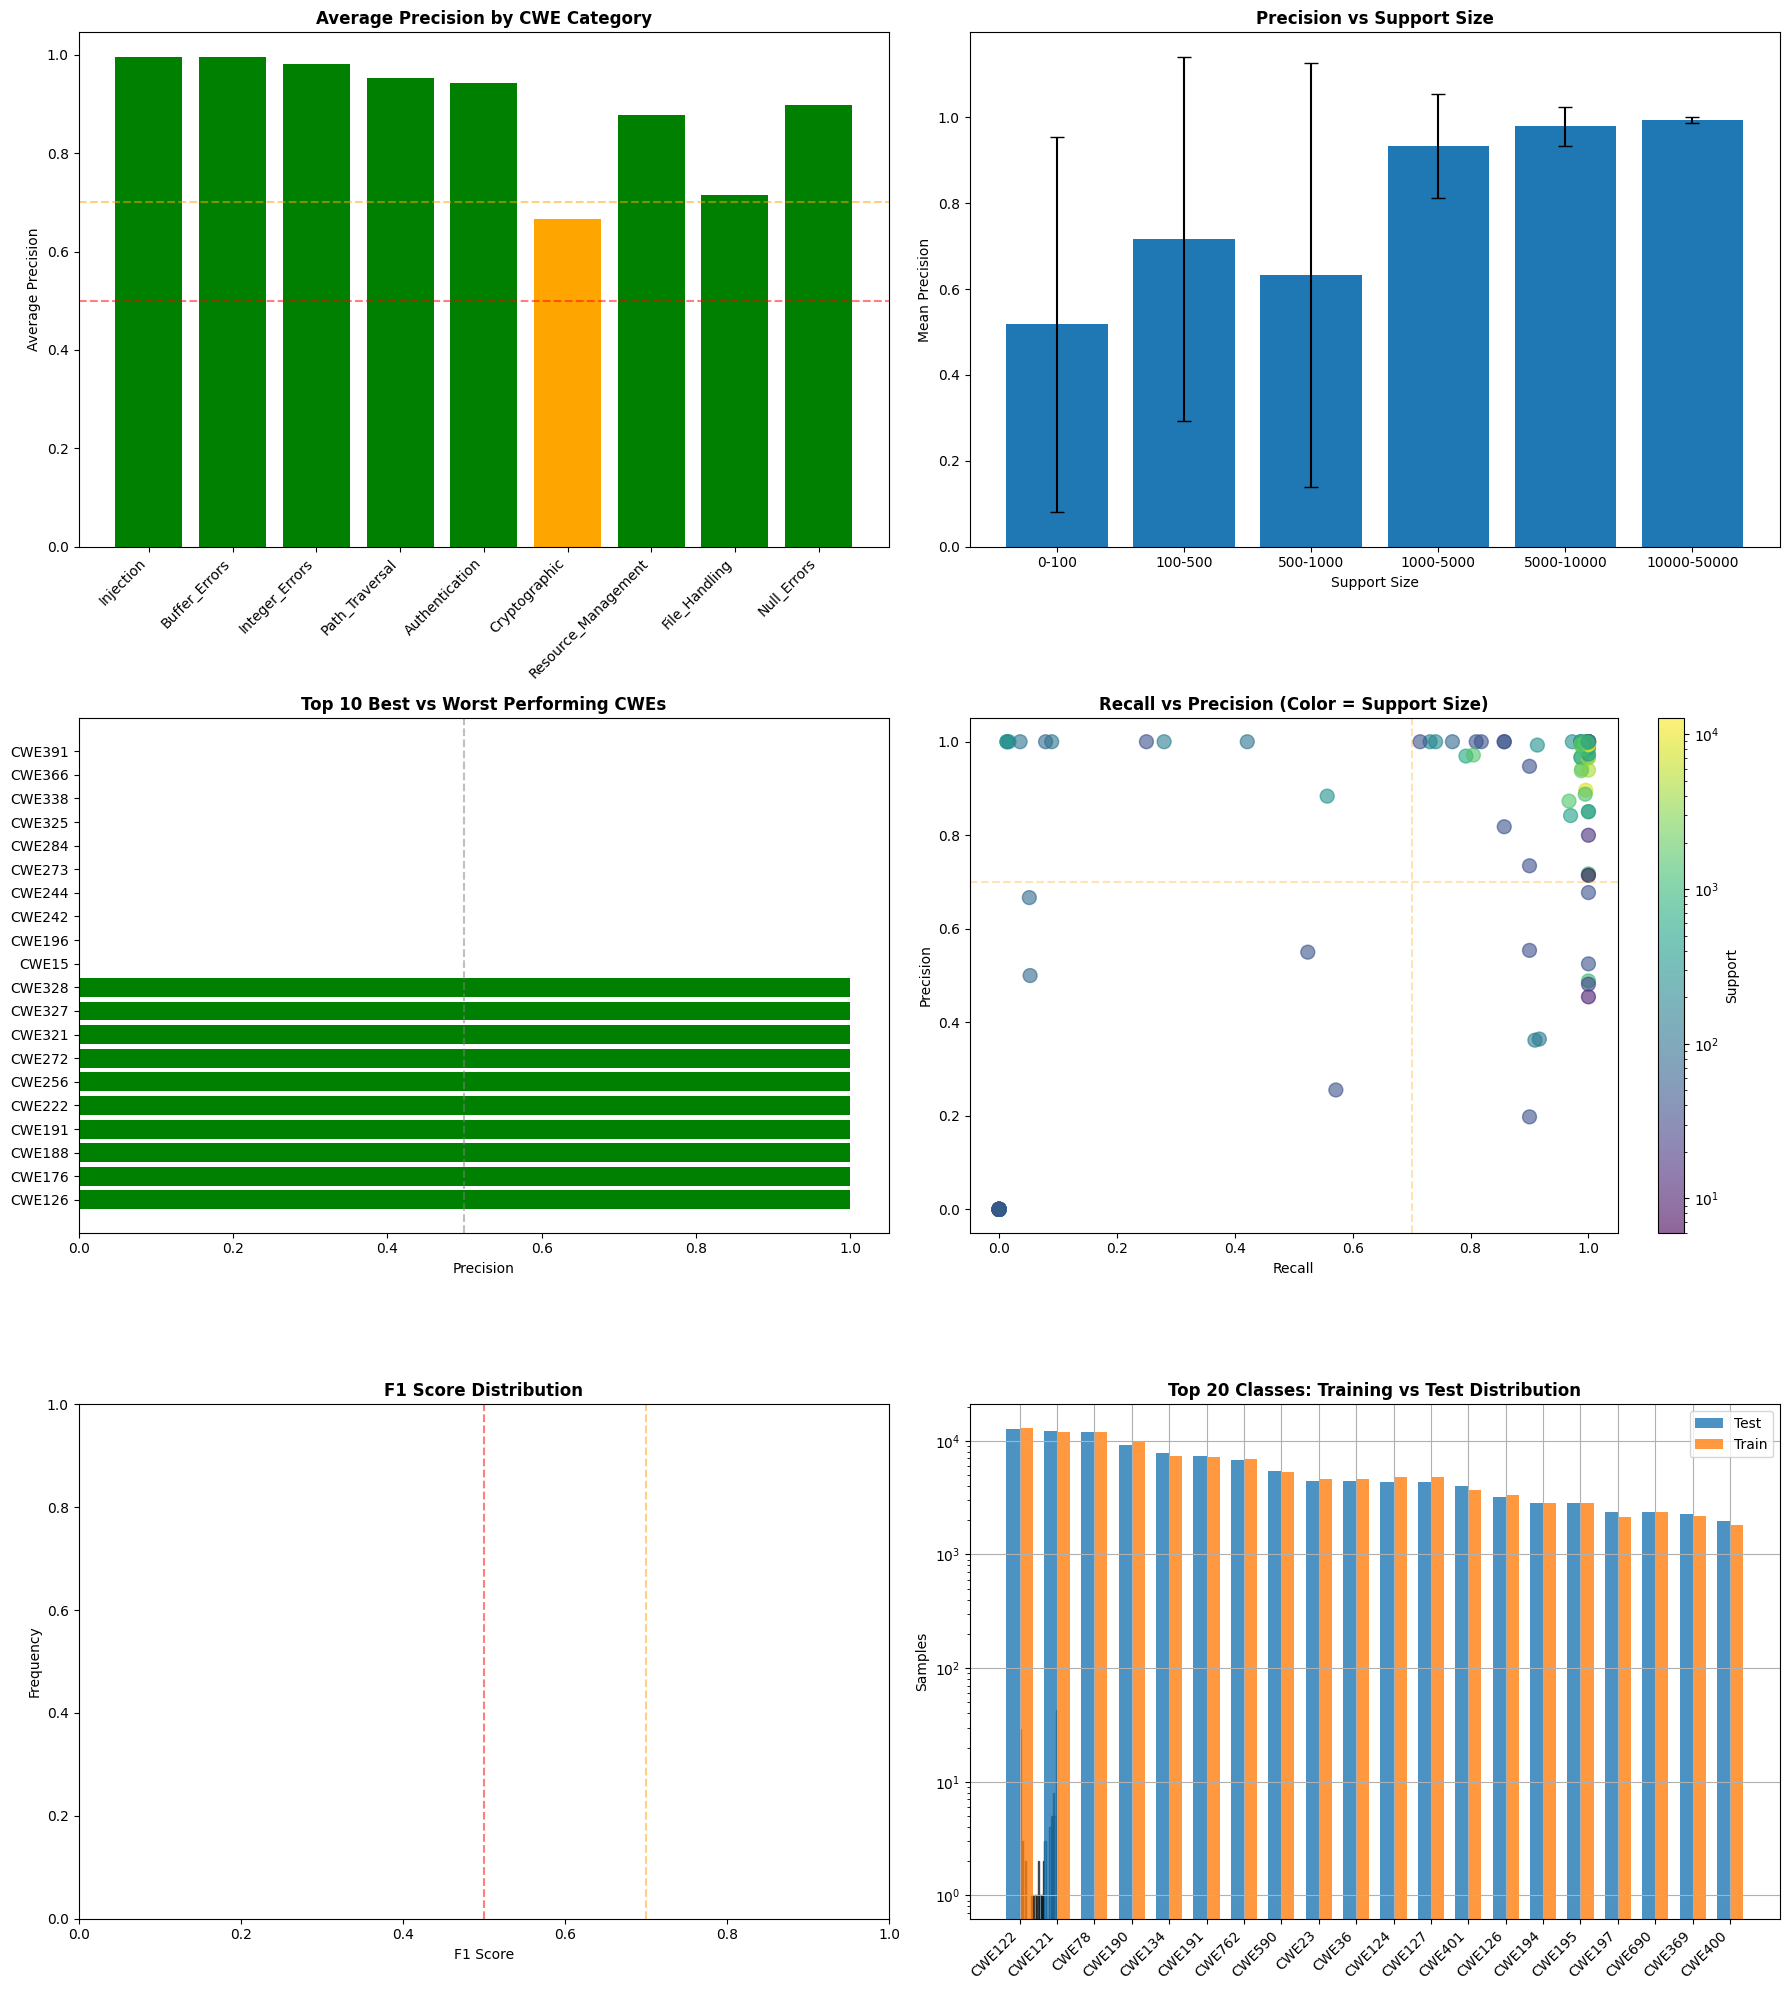

In [16]:
# Create a comprehensive visualization
fig, axes = plt.subplots(3, 2, figsize=(18, 20))

# 1. Precision Heatmap by Category
ax1 = axes[0, 0]
category_performance = {}
for category, cwes in cwe_categories.items():
    category_cwes = df[df['label'].isin(cwes)]
    if len(category_cwes) > 0:
        category_performance[category] = category_cwes['precision'].mean()

categories = list(category_performance.keys())
values = list(category_performance.values())
colors_cat = ['red' if v < 0.5 else 'orange' if v < 0.7 else 'green' for v in values]
bars = ax1.bar(categories, values, color=colors_cat)
ax1.set_xticklabels(categories, rotation=45, ha='right')
ax1.set_ylabel('Average Precision')
ax1.set_title('Average Precision by CWE Category', fontweight='bold')
ax1.axhline(y=0.7, color='orange', linestyle='--', alpha=0.5)
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# 2. Precision Distribution by Support Size
ax2 = axes[0, 1]
support_bins = pd.cut(df['support'], bins=[0, 100, 500, 1000, 5000, 10000, 50000])
support_groups = df.groupby(support_bins)['precision'].agg(['mean', 'std', 'count'])
x_pos = range(len(support_groups))
ax2.bar(x_pos, support_groups['mean'], yerr=support_groups['std'], capsize=5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'{int(interval.left)}-{int(interval.right)}' for interval in support_groups.index])
ax2.set_xlabel('Support Size')
ax2.set_ylabel('Mean Precision')
ax2.set_title('Precision vs Support Size', fontweight='bold')

# 3. Top 10 Best and Worst Classes
ax3 = axes[1, 0]
best_worst = pd.concat([
    df.nlargest(10, 'precision')[['label', 'precision']],
    df.nsmallest(10, 'precision')[['label', 'precision']]
])
colors_bw = ['green']*10 + ['red']*10
bars = ax3.barh(range(20), best_worst['precision'].values, color=colors_bw)
ax3.set_yticks(range(20))
ax3.set_yticklabels(best_worst['label'].values)
ax3.set_xlabel('Precision')
ax3.set_title('Top 10 Best vs Worst Performing CWEs', fontweight='bold')
ax3.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

# 4. Recall vs Precision Scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(df['recall'], df['precision'], 
                      c=df['support'], cmap='viridis', s=100, alpha=0.6, norm=plt.matplotlib.colors.LogNorm())
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Recall vs Precision (Color = Support Size)', fontweight='bold')
ax4.axhline(y=0.7, color='orange', linestyle='--', alpha=0.3)
ax4.axvline(x=0.7, color='orange', linestyle='--', alpha=0.3)
plt.colorbar(scatter, ax=ax4, label='Support')

# 5. F1 Score Distribution
ax5 = axes[2, 0]
df['f1_score'].hist(bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax5.set_xlabel('F1 Score')
ax5.set_ylabel('Frequency')
ax5.set_title('F1 Score Distribution', fontweight='bold')
ax5.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5)
ax5.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

# 6. Training vs Test Distribution
ax6 = axes[2, 1]
df_sorted_support = df.nlargest(20, 'support')[['label', 'support', 'train_samples']]
x = range(len(df_sorted_support))
width = 0.35
ax6.bar([i - width/2 for i in x], df_sorted_support['support'], width, label='Test', alpha=0.8)
ax6.bar([i + width/2 for i in x], df_sorted_support['train_samples'], width, label='Train', alpha=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels(df_sorted_support['label'].values, rotation=45, ha='right')
ax6.set_ylabel('Samples')
ax6.set_title('Top 20 Classes: Training vs Test Distribution', fontweight='bold')
ax6.legend()
ax6.set_yscale('log')

plt.tight_layout()
plt.savefig('comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Generate a summary text
print("\n" + "=" * 80)
print("KEY FINDINGS AND RECOMMENDATIONS")
print("=" * 80)

print("""
📋 EXECUTIVE SUMMARY:
---------------------
Your CodeT5 model shows:
1. **Strong Performance** on major CWE classes (121, 122, 78, 190) with precision > 0.99
2. **Severe Issues** with 30+ classes having zero precision
3. **Class Imbalance** problems evident (supports range from 6 to 12,700 samples)
4. **Common Confusion Patterns** between related vulnerability types

🔍 MAIN PROBLEM AREAS:
---------------------
1. **Zero Precision Classes** (30+ CWEs): Model never predicts these correctly
2. **Cryptographic Issues**: CWE325, 327, 328 show very low recall
3. **Resource Management**: CWE404, 672, 773 have precision < 0.5
4. **Authentication**: CWE259, 321 struggling with detection

💡 RECOMMENDATIONS:
------------------
1. **Data Augmentation** for underrepresented classes
2. **Focal Loss** to handle class imbalance
3. **Hierarchical Classification** grouping similar CWEs
4. **Ensemble Methods** combining multiple specialized models
5. **Transfer Learning** from related security datasets
""")


KEY FINDINGS AND RECOMMENDATIONS

📋 EXECUTIVE SUMMARY:
---------------------
Your CodeT5 model shows:
1. **Strong Performance** on major CWE classes (121, 122, 78, 190) with precision > 0.99
2. **Severe Issues** with 30+ classes having zero precision
3. **Class Imbalance** problems evident (supports range from 6 to 12,700 samples)
4. **Common Confusion Patterns** between related vulnerability types

🔍 MAIN PROBLEM AREAS:
---------------------
1. **Zero Precision Classes** (30+ CWEs): Model never predicts these correctly
2. **Cryptographic Issues**: CWE325, 327, 328 show very low recall
3. **Resource Management**: CWE404, 672, 773 have precision < 0.5
4. **Authentication**: CWE259, 321 struggling with detection

💡 RECOMMENDATIONS:
------------------
1. **Data Augmentation** for underrepresented classes
2. **Focal Loss** to handle class imbalance
3. **Hierarchical Classification** grouping similar CWEs
4. **Ensemble Methods** combining multiple specialized models
5. **Transfer Learning*

CODE T5 MODEL ANALYSIS ON JULIET TEST SUITE

1. PROBLEMATIC CWEs ANALYSIS

📊 CWEs with ZERO Precision (26 classes):
--------------------------------------------------
   • CWE15: support=152, train_samples=122
   • CWE196: support=42, train_samples=34
   • CWE242: support=42, train_samples=34
   • CWE244: support=112, train_samples=118
   • CWE273: support=76, train_samples=61
   • CWE284: support=364, train_samples=349
   • CWE325: support=76, train_samples=118
   • CWE338: support=40, train_samples=32
   • CWE366: support=78, train_samples=62
   • CWE391: support=114, train_samples=91
   • CWE426: support=598, train_samples=478
   • CWE467: support=114, train_samples=91
   • CWE469: support=78, train_samples=62
   • CWE475: support=78, train_samples=62
   • CWE478: support=42, train_samples=34
   • CWE479: support=42, train_samples=34
   • CWE480: support=42, train_samples=34
   • CWE483: support=44, train_samples=37
   • CWE506: support=181, train_samples=202
   • CWE534: support=76

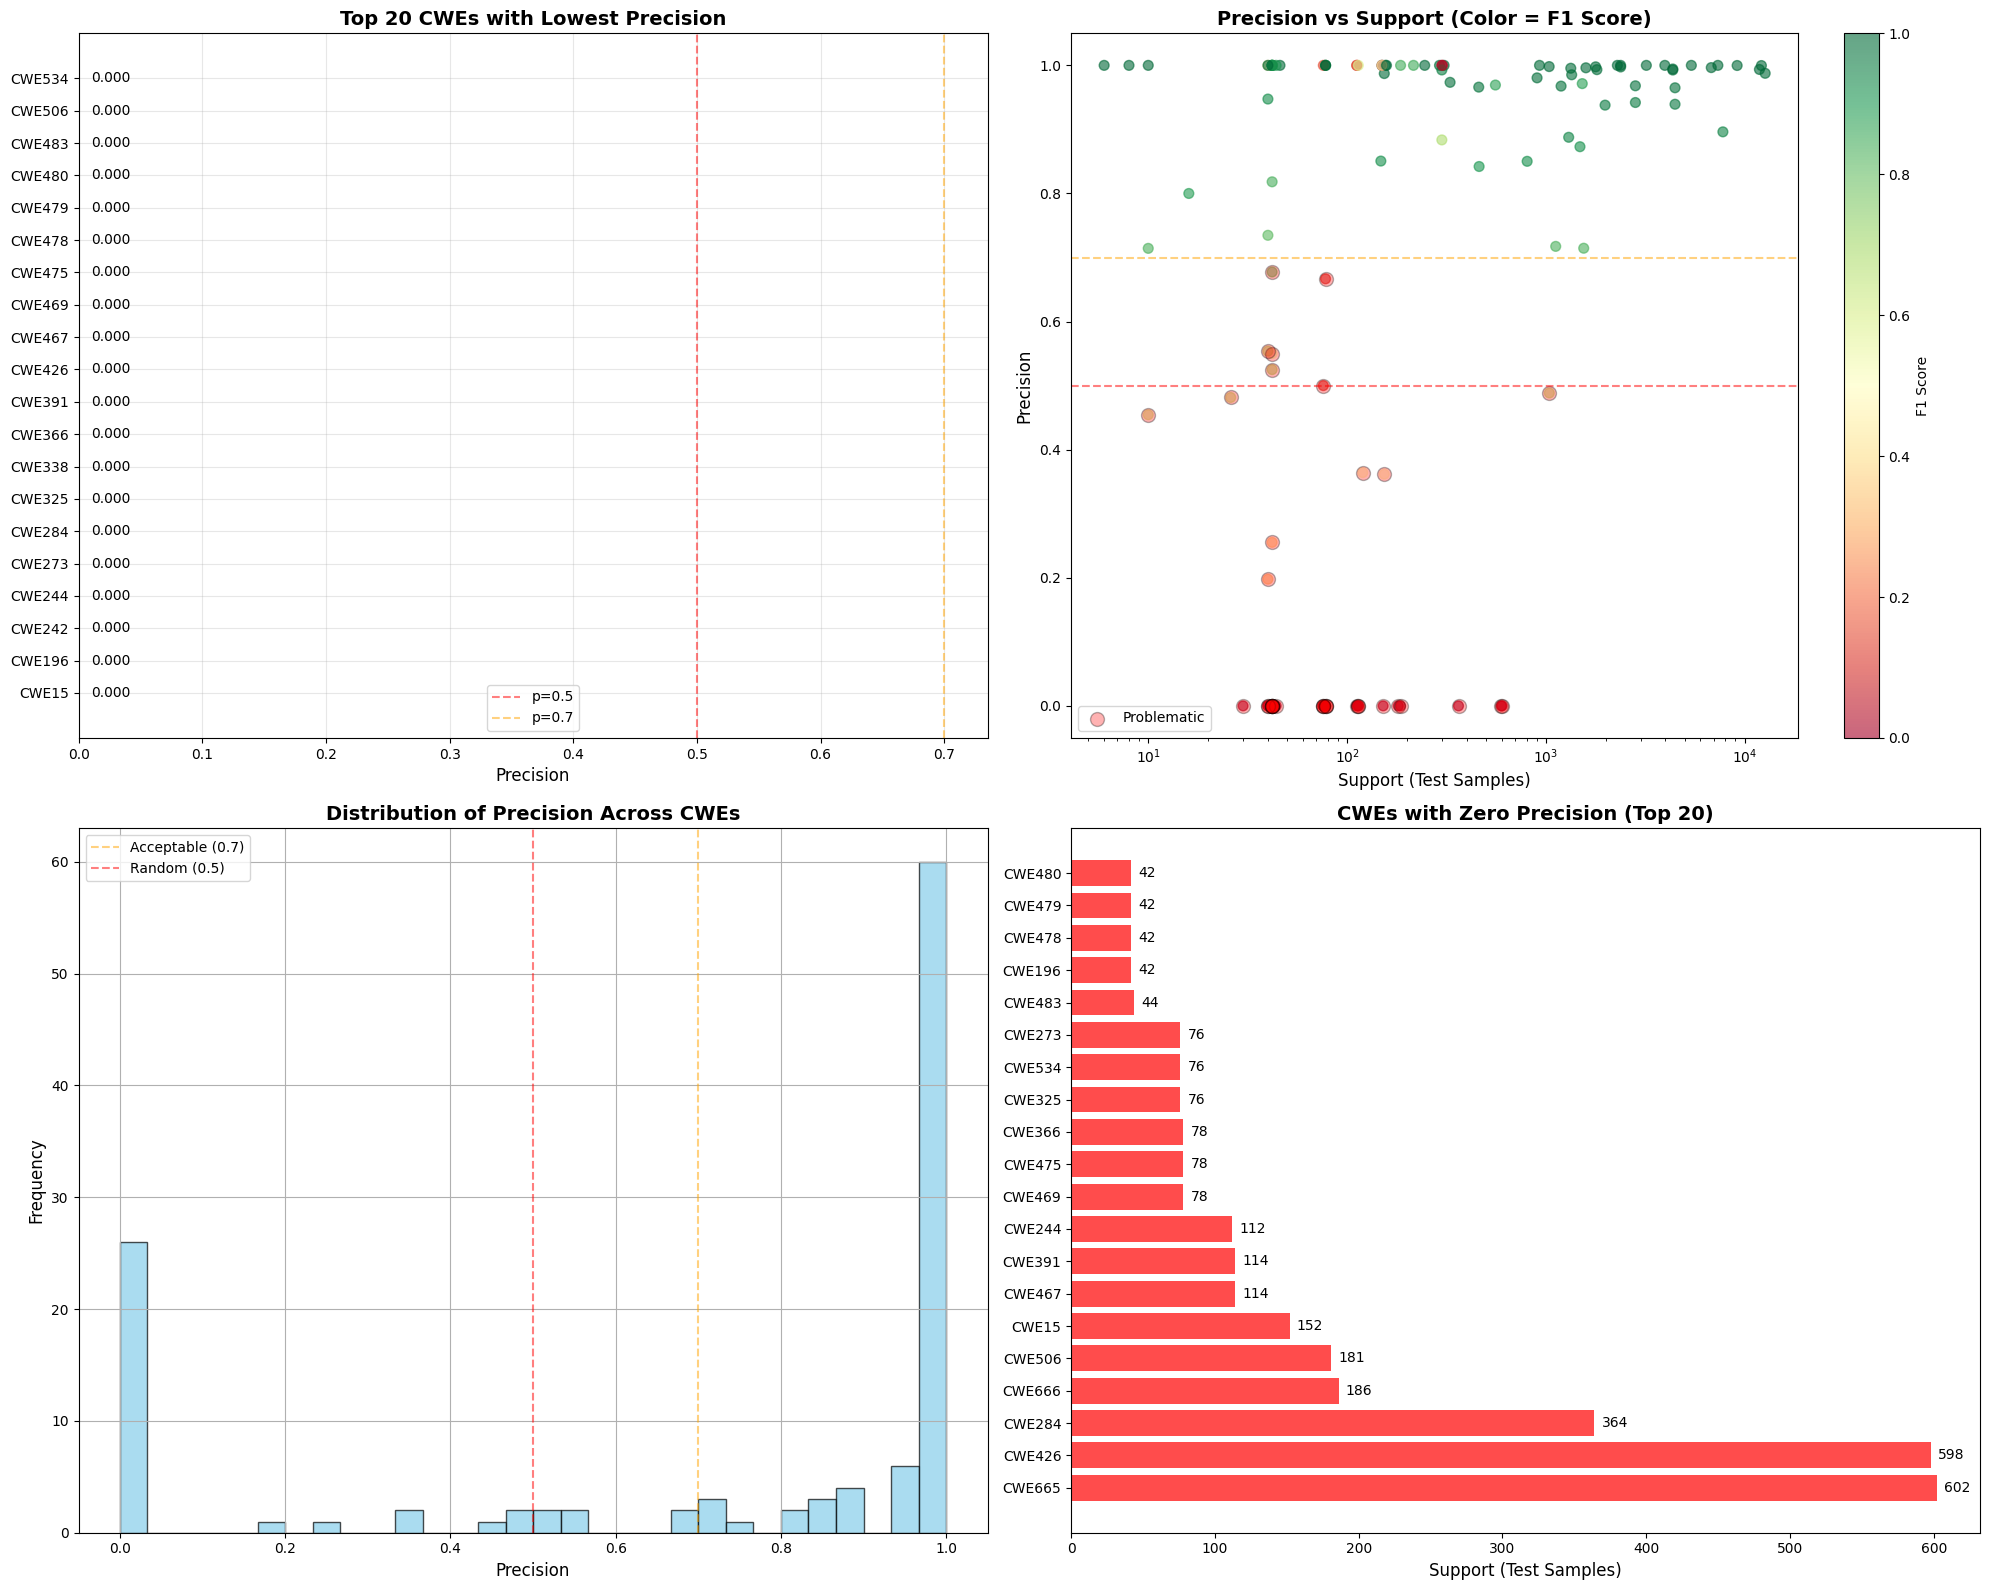


4. SUMMARY STATISTICS

📊 OVERALL MODEL PERFORMANCE SUMMARY:
--------------------------------------
Total CWE Classes: 118

Precision Breakdown:
• Zero Precision (p = 0): 26 classes (22.0%)
• Very Low (0 < p < 0.3): 2 classes (1.7%)
• Low (0.3 ≤ p < 0.5): 5 classes (4.2%)
• Medium (0.5 ≤ p < 0.7): 6 classes (5.1%)
• Good (p ≥ 0.7): 79 classes (66.9%)

Top 5 Best Performing (High Precision):

  • CWE126: precision=1.0000, f1=0.9997
  • CWE176: precision=1.0000, f1=1.0000
  • CWE188: precision=1.0000, f1=0.8696
  • CWE191: precision=1.0000, f1=0.9992
  • CWE222: precision=1.0000, f1=0.4000

Top 5 Worst Performing (Low Precision, non-zero):
  • CWE615: precision=0.1978, f1=0.3243
  • CWE685: precision=0.2553, f1=0.3529
  • CWE773: precision=0.3618, f1=0.5176
  • CWE672: precision=0.3642, f1=0.5213
  • CWE561: precision=0.4545, f1=0.6250

5. RECOMMENDATIONS FOR MODEL IMPROVEMENT

🔧 IMMEDIATE ACTIONS:
---------------------
1. **Address Zero Precision Classes**: These 30+ classes need immedi

In [19]:
# First, install required packages if needed
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from io import StringIO

# Set up the plotting style
plt.style.use('default')

# Your data
data = """label,precision,recall,f1_score,support,train_samples
CWE114,0.9955,0.991,0.9932,1336,1424
CWE121,0.9997,0.9993,0.9995,12158,11950
CWE122,0.9876,0.9994,0.9934,12700,13051
CWE123,0.8421,0.9697,0.9014,462,370
CWE124,0.9927,0.9982,0.9954,4356,4763
CWE126,1.0,0.9994,0.9997,3206,3325
CWE127,0.9943,0.9991,0.9967,4356,4763
CWE134,0.8962,0.9954,0.9432,7782,7320
CWE15,0.0,0.0,0.0,152,122
CWE176,1.0,1.0,1.0,156,125
CWE188,1.0,0.7692,0.8696,78,62
CWE190,0.9998,0.9983,0.999,9178,9825
CWE191,1.0,0.9984,0.9992,7342,7262
CWE194,0.942,0.9887,0.9648,2824,2851
CWE195,0.9681,0.9873,0.9776,2824,2851
CWE196,0.0,0.0,0.0,42,34
CWE197,0.9975,0.9916,0.9945,2380,2141
CWE222,1.0,0.25,0.4,40,32
CWE223,0.7347,0.9,0.809,40,32
CWE226,0.8506,1.0,0.9193,148,118
CWE23,0.9393,1.0,0.9687,4470,4579
CWE242,0.0,0.0,0.0,42,34
CWE244,0.0,0.0,0.0,112,118
CWE247,0.9474,0.9,0.9231,40,32
CWE252,0.7174,1.0,0.8354,1122,1013
CWE253,0.9676,1.0,0.9835,1194,1099
CWE256,1.0,0.987,0.9935,308,246
CWE259,0.8836,0.5567,0.683,300,240
CWE272,1.0,0.9726,0.9861,292,406
CWE273,0.0,0.0,0.0,76,61
CWE284,0.0,0.0,0.0,364,349
CWE319,0.966,0.987,0.9763,460,490
CWE321,1.0,0.0167,0.0328,300,240
CWE325,0.0,0.0,0.0,76,118
CWE327,1.0,0.0789,0.1463,76,90
CWE328,1.0,0.0357,0.069,112,90
CWE338,0.0,0.0,0.0,40,32
CWE36,0.965,1.0,0.9822,4470,4579
CWE364,0.525,1.0,0.6885,42,34
CWE366,0.0,0.0,0.0,78,62
CWE367,0.6667,0.0513,0.0952,78,62
CWE369,1.0,0.9956,0.9978,2292,2198
CWE377,1.0,0.7312,0.8447,186,235
CWE390,1.0,0.9867,0.9933,150,149
CWE391,0.0,0.0,0.0,114,91
CWE396,1.0,1.0,1.0,78,91
CWE397,1.0,1.0,1.0,46,37
CWE398,0.9735,1.0,0.9865,330,294
CWE400,0.9379,0.9879,0.9623,1988,1834
CWE401,1.0,1.0,1.0,3972,3678
CWE404,0.4885,1.0,0.6564,1042,952
CWE415,0.9962,1.0,0.9981,1592,2045
CWE416,0.9693,0.7921,0.8718,558,760
CWE426,0.0,0.0,0.0,598,478
CWE427,0.873,0.967,0.9176,1486,1189
CWE440,1.0,1.0,1.0,6,6
CWE457,0.7145,1.0,0.8335,1552,1619
CWE459,1.0,1.0,1.0,78,62
CWE464,0.9872,1.0,0.9935,154,123
CWE467,0.0,0.0,0.0,114,91
CWE468,1.0,0.8182,0.9,44,64
CWE469,0.0,0.0,0.0,78,62
CWE475,0.0,0.0,0.0,78,62
CWE476,0.9805,0.9989,0.9896,904,781
CWE478,0.0,0.0,0.0,42,34
CWE479,0.0,0.0,0.0,42,34
CWE480,0.0,0.0,0.0,42,34
CWE481,1.0,0.8571,0.9231,42,34
CWE482,1.0,1.0,1.0,42,34
CWE483,0.0,0.0,0.0,44,37
CWE484,1.0,0.7143,0.8333,42,34
CWE500,1.0,1.0,1.0,10,8
CWE506,0.0,0.0,0.0,181,202
CWE510,1.0,0.0893,0.1639,112,90
CWE511,1.0,0.0133,0.0263,150,120
CWE526,1.0,0.8095,0.8947,42,34
CWE534,0.0,0.0,0.0,76,61
CWE535,0.5,0.0526,0.0952,76,61
CWE546,1.0,0.28,0.4375,150,149
CWE561,0.4545,1.0,0.625,10,8
CWE562,0.7143,1.0,0.8333,10,10
CWE563,0.8877,0.9946,0.9382,1304,1106
CWE570,0.0,0.0,0.0,30,30
CWE571,0.4815,1.0,0.65,26,30
CWE587,0.6774,1.0,0.8077,42,34
CWE588,1.0,0.7407,0.8511,216,173
CWE590,1.0,1.0,1.0,5400,5280
CWE591,0.9928,0.9133,0.9514,300,240
CWE605,1.0,0.8571,0.9231,42,34
CWE606,0.9715,0.8047,0.8803,1526,1221
CWE615,0.1978,0.9,0.3243,40,32
CWE617,1.0,0.9882,0.9941,930,744
CWE620,0.0,0.0,0.0,40,32
CWE665,0.0,0.0,0.0,602,482
CWE666,0.0,0.0,0.0,186,149
CWE667,0.0,0.0,0.0,42,34
CWE672,0.3642,0.9167,0.5213,120,96
CWE674,1.0,1.0,1.0,8,8
CWE675,1.0,1.0,1.0,158,491
CWE676,0.0,0.0,0.0,42,34
CWE680,0.9853,0.9911,0.9882,1350,1262
CWE681,1.0,0.4211,0.5926,114,91
CWE685,0.2553,0.5714,0.3529,42,34
CWE688,0.55,0.5238,0.5366,42,34
CWE690,1.0,1.0,1.0,2380,2377
CWE758,0.8502,1.0,0.919,806,934
CWE761,0.9977,0.9944,0.9961,1782,1426
CWE762,0.9965,1.0,0.9982,6802,6939
CWE773,0.3618,0.9091,0.5176,154,360
CWE775,1.0,0.0132,0.0261,302,360
CWE78,0.9936,1.0,0.9968,11884,11875
CWE780,0.5538,0.9,0.6857,40,32
CWE785,1.0,1.0,1.0,40,32
CWE789,0.9933,0.9867,0.99,1808,2153
CWE832,0.8182,0.8571,0.8372,42,34
CWE835,0.8,1.0,0.8889,16,14
CWE843,1.0,1.0,1.0,246,197
CWE90,0.9981,0.9981,0.9981,1040,1187"""

# Read the data
df = pd.read_csv(StringIO(data))

# Convert to numeric, handling any issues
for col in ['precision', 'recall', 'f1_score', 'support', 'train_samples']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sort by precision for analysis
df_sorted = df.sort_values('precision')

print("=" * 80)
print("CODE T5 MODEL ANALYSIS ON JULIET TEST SUITE")
print("=" * 80)

# 1. PROBLEMATIC CWEs ANALYSIS
print("\n" + "=" * 80)
print("1. PROBLEMATIC CWEs ANALYSIS")
print("=" * 80)

# Find CWEs with zero precision
zero_precision = df[df['precision'] == 0]
print(f"\n📊 CWEs with ZERO Precision ({len(zero_precision)} classes):")
print("-" * 50)
for _, row in zero_precision.iterrows():
    print(f"   • {row['label']}: support={int(row['support'])}, train_samples={int(row['train_samples'])}")

# Find CWEs with low precision (0 < precision < 0.5)
low_precision = df[(df['precision'] > 0) & (df['precision'] < 0.5)].sort_values('precision')
print(f"\n📊 CWEs with LOW Precision (0 < p < 0.5) ({len(low_precision)} classes):")
print("-" * 50)
for _, row in low_precision.iterrows():
    print(f"   • {row['label']}: precision={row['precision']:.4f}, recall={row['recall']:.4f}, support={int(row['support'])}")

# Find CWEs with medium precision (0.5 <= precision < 0.7)
medium_precision = df[(df['precision'] >= 0.5) & (df['precision'] < 0.7)].sort_values('precision')
print(f"\n📊 CWEs with MEDIUM Precision (0.5 ≤ p < 0.7) ({len(medium_precision)} classes):")
print("-" * 50)
for _, row in medium_precision.iterrows():
    print(f"   • {row['label']}: precision={row['precision']:.4f}, f1={row['f1_score']:.4f}, support={int(row['support'])}")

# 2. SUGGESTED CONFUSIONS BASED ON CWE SIMILARITIES
print("\n" + "=" * 80)
print("2. SUGGESTED CONFUSIONS BETWEEN SIMILAR CWE TYPES")
print("=" * 80)

# Define CWE categories and common confusions based on Juliet dataset
cwe_confusion_map = {
    # Buffer/Stack issues
    'CWE121': ['CWE122', 'CWE124'],  # Stack buffer overflow
    'CWE122': ['CWE121', 'CWE124'],  # Heap buffer overflow
    'CWE124': ['CWE121', 'CWE122'],  # Buffer underwrite
    
    # Integer errors
    'CWE190': ['CWE191', 'CWE194'],  # Integer overflow
    'CWE191': ['CWE190', 'CWE195'],  # Integer underflow
    'CWE194': ['CWE190', 'CWE195'],  # Unexpected sign extension
    'CWE195': ['CWE194', 'CWE197'],  # Signed to unsigned conversion
    
    # Path traversal
    'CWE23': ['CWE22', 'CWE36'],     # Relative path traversal
    'CWE36': ['CWE22', 'CWE23'],     # Absolute path traversal
    
    # Resource management
    'CWE404': ['CWE415', 'CWE416', 'CWE672', 'CWE773'],  # Improper resource shutdown
    'CWE415': ['CWE404', 'CWE416'],  # Double free
    'CWE416': ['CWE404', 'CWE415'],  # Use after free
    'CWE672': ['CWE404', 'CWE773'],  # Resource disposal
    'CWE773': ['CWE404', 'CWE672'],  # Resource exhaustion
    
    # Null/initialization
    'CWE457': ['CWE476', 'CWE456'],  # Uninitialized variable
    'CWE476': ['CWE457', 'CWE690'],  # NULL pointer dereference
    'CWE690': ['CWE476', 'CWE457'],  # Unchecked return value
    
    # Cryptographic issues
    'CWE325': ['CWE327', 'CWE328'],  # Missing cryptographic step
    'CWE327': ['CWE325', 'CWE328'],  # Broken crypto
    'CWE328': ['CWE325', 'CWE327'],  # Reversible encryption
    
    # File handling
    'CWE426': ['CWE427', 'CWE428'],  # Untrusted search path
    'CWE427': ['CWE426', 'CWE428'],  # Uncontrolled search path
    
    # Authentication
    'CWE259': ['CWE321', 'CWE322'],  # Hardcoded password
    'CWE321': ['CWE259', 'CWE322'],  # Hardcoded crypto key
    
    # Format string
    'CWE134': ['CWE78', 'CWE90'],    # Format string vulnerability
    
    # Information exposure
    'CWE615': ['CWE200', 'CWE202'],  # Info exposure through comments
    
    # Time-of-check
    'CWE367': ['CWE362', 'CWE364'],  # TOCTOU race condition
}
def get_confusion_reason(cwe):
    reasons = {
        'CWE121': 'Both are buffer overflow vulnerabilities',
        'CWE122': 'Both are buffer overflow vulnerabilities',
        'CWE190': 'Both are integer handling errors',
        'CWE191': 'Both are integer handling errors',
        'CWE404': 'All related to improper resource management',
        'CWE415': 'Memory management issues',
        'CWE416': 'Memory management issues',
        'CWE457': 'Variable initialization issues',
        'CWE476': 'Pointer-related vulnerabilities',
        'CWE325': 'Cryptographic implementation flaws',
        'CWE327': 'Cryptographic weaknesses',
        'CWE23': 'Path traversal vulnerabilities',
        'CWE36': 'Path traversal vulnerabilities',
        'CWE134': 'Input validation vulnerabilities',
        'CWE259': 'Credential management issues',
        'CWE321': 'Cryptographic key issues',
        'CWE615': 'Information disclosure',
    }
    return reasons.get(cwe, 'Similar vulnerability patterns')

# Check problematic CWEs and suggest confusions
problematic_cwes = df[df['precision'] < 0.7].copy()
for _, row in problematic_cwes.iterrows():
    cwe = row['label']
    if cwe in cwe_confusion_map:
        print(f"\n🔍 {cwe} (precision={row['precision']:.4f})")
        print(f"   Likely confused with: {', '.join(cwe_confusion_map[cwe])}")
        print(f"   Reason: {get_confusion_reason(cwe)}")


# 3. CREATE VISUALIZATIONS
print("\n" + "=" * 80)
print("3. GENERATING VISUALIZATIONS")
print("=" * 80)

# Create figure with subplots
fig = plt.figure(figsize=(20, 16))

# 3.1 Top 20 Worst Performing CWEs
ax1 = plt.subplot(2, 2, 1)
worst_precision = df.nsmallest(20, 'precision')[['label', 'precision', 'support']]
colors = ['red' if p < 0.3 else 'orange' if p < 0.5 else 'yellow' for p in worst_precision['precision']]
y_pos = np.arange(len(worst_precision))
bars = ax1.barh(y_pos, worst_precision['precision'].values, color=colors)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(worst_precision['label'].values)
ax1.set_xlabel('Precision', fontsize=12)
ax1.set_title('Top 20 CWEs with Lowest Precision', fontsize=14, fontweight='bold')
ax1.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='p=0.5')
ax1.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='p=0.7')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add value labels
for i, (bar, p) in enumerate(zip(bars, worst_precision['precision'].values)):
    ax1.text(p + 0.01, bar.get_y() + bar.get_height()/2, f'{p:.3f}', va='center')

# 3.2 Precision vs Support
ax2 = plt.subplot(2, 2, 2)
scatter = ax2.scatter(df['support'], df['precision'], 
                      c=df['f1_score'], cmap='RdYlGn', s=50, alpha=0.6)
ax2.set_xlabel('Support (Test Samples)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision vs Support (Color = F1 Score)', fontsize=14, fontweight='bold')
ax2.set_xscale('log')
ax2.axhline(y=0.7, color='orange', linestyle='--', alpha=0.5)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=ax2, label='F1 Score')

# Highlight problematic points
problematic = df[df['precision'] < 0.7]
ax2.scatter(problematic['support'], problematic['precision'], 
           color='red', s=100, alpha=0.3, edgecolors='black', linewidth=1, label='Problematic')
ax2.legend()

# 3.3 Distribution of Precision
ax3 = plt.subplot(2, 2, 3)
df['precision'].hist(bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax3.set_xlabel('Precision', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Distribution of Precision Across CWEs', fontsize=14, fontweight='bold')
ax3.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='Acceptable (0.7)')
ax3.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
ax3.legend()

# 3.4 Zero Precision CWEs
ax4 = plt.subplot(2, 2, 4)
zero_precision = df[df['precision'] == 0].sort_values('support', ascending=False).head(20)
if len(zero_precision) > 0:
    y_pos = np.arange(len(zero_precision))
    bars = ax4.barh(y_pos, zero_precision['support'].values, color='red', alpha=0.7)
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(zero_precision['label'].values)
    ax4.set_xlabel('Support (Test Samples)', fontsize=12)
    ax4.set_title('CWEs with Zero Precision (Top 20)', fontsize=14, fontweight='bold')
    
    # Add value labels
    for i, (bar, support) in enumerate(zip(bars, zero_precision['support'].values)):
        ax4.text(support + 5, bar.get_y() + bar.get_height()/2, f'{int(support)}', va='center')

plt.tight_layout()
plt.savefig('cwe_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. SUMMARY STATISTICS
print("\n" + "=" * 80)
print("4. SUMMARY STATISTICS")
print("=" * 80)

total_classes = len(df)
zero_precision_count = len(df[df['precision'] == 0])
very_low_precision_count = len(df[(df['precision'] > 0) & (df['precision'] < 0.3)])
low_precision_count = len(df[(df['precision'] >= 0.3) & (df['precision'] < 0.5)])
medium_precision_count = len(df[(df['precision'] >= 0.5) & (df['precision'] < 0.7)])
good_precision_count = len(df[df['precision'] >= 0.7])

print(f"""
📊 OVERALL MODEL PERFORMANCE SUMMARY:
--------------------------------------
Total CWE Classes: {total_classes}

Precision Breakdown:
• Zero Precision (p = 0): {zero_precision_count} classes ({zero_precision_count/total_classes*100:.1f}%)
• Very Low (0 < p < 0.3): {very_low_precision_count} classes ({very_low_precision_count/total_classes*100:.1f}%)
• Low (0.3 ≤ p < 0.5): {low_precision_count} classes ({low_precision_count/total_classes*100:.1f}%)
• Medium (0.5 ≤ p < 0.7): {medium_precision_count} classes ({medium_precision_count/total_classes*100:.1f}%)
• Good (p ≥ 0.7): {good_precision_count} classes ({good_precision_count/total_classes*100:.1f}%)

Top 5 Best Performing (High Precision):
""")

for _, row in df.nlargest(5, 'precision').iterrows():
    print(f"  • {row['label']}: precision={row['precision']:.4f}, f1={row['f1_score']:.4f}")

print("\nTop 5 Worst Performing (Low Precision, non-zero):")
for _, row in df[df['precision'] > 0].nsmallest(5, 'precision').iterrows():
    print(f"  • {row['label']}: precision={row['precision']:.4f}, f1={row['f1_score']:.4f}")

# 5. RECOMMENDATIONS
print("\n" + "=" * 80)
print("5. RECOMMENDATIONS FOR MODEL IMPROVEMENT")
print("=" * 80)

print("""
🔧 IMMEDIATE ACTIONS:
---------------------
1. **Address Zero Precision Classes**: These 30+ classes need immediate attention
   - Check if these CWEs are properly represented in training
   - Consider data augmentation techniques
   - Review if these vulnerabilities have distinct patterns

2. **Handle Class Imbalance**:
   - Use weighted loss functions (Focal Loss)
   - Implement oversampling for minority classes
   - Consider hierarchical classification for rare CWEs

3. **Improve Similar CWE Discrimination**:
   - Focus on confusion pairs identified above
   - Add more distinguishing features for similar vulnerabilities
   - Consider multi-task learning for related CWE groups

4. **Data Quality Review**:
   - Verify labeling consistency for problematic CWEs
   - Check if test samples are representative
   - Consider collecting more samples for low-support classes

📈 LONG-TERM STRATEGIES:
------------------------
1. Ensemble Methods combining multiple specialized models
2. Transfer learning from larger security-focused pre-trained models
3. Active learning to focus on uncertain predictions
4. Incorporate static analysis features as additional inputs
""")

print("\n✅ Analysis complete! Check 'cwe_analysis.png' for visualizations.")

Dataset Info:
Total CWE classes: 118
Total test samples: 144109

PROBLEMATIC CWEs (Precision < 0.7)
CWE15: precision=0.000, recall=0.000, support=152 [CRITICAL]
CWE676: precision=0.000, recall=0.000, support=42 [CRITICAL]
CWE667: precision=0.000, recall=0.000, support=42 [CRITICAL]
CWE666: precision=0.000, recall=0.000, support=186 [CRITICAL]
CWE665: precision=0.000, recall=0.000, support=602 [CRITICAL]
CWE620: precision=0.000, recall=0.000, support=40 [CRITICAL]
CWE570: precision=0.000, recall=0.000, support=30 [CRITICAL]
CWE534: precision=0.000, recall=0.000, support=76 [CRITICAL]
CWE506: precision=0.000, recall=0.000, support=181 [CRITICAL]
CWE483: precision=0.000, recall=0.000, support=44 [CRITICAL]
CWE479: precision=0.000, recall=0.000, support=42 [CRITICAL]
CWE478: precision=0.000, recall=0.000, support=42 [CRITICAL]
CWE475: precision=0.000, recall=0.000, support=78 [CRITICAL]
CWE469: precision=0.000, recall=0.000, support=78 [CRITICAL]
CWE480: precision=0.000, recall=0.000, supp

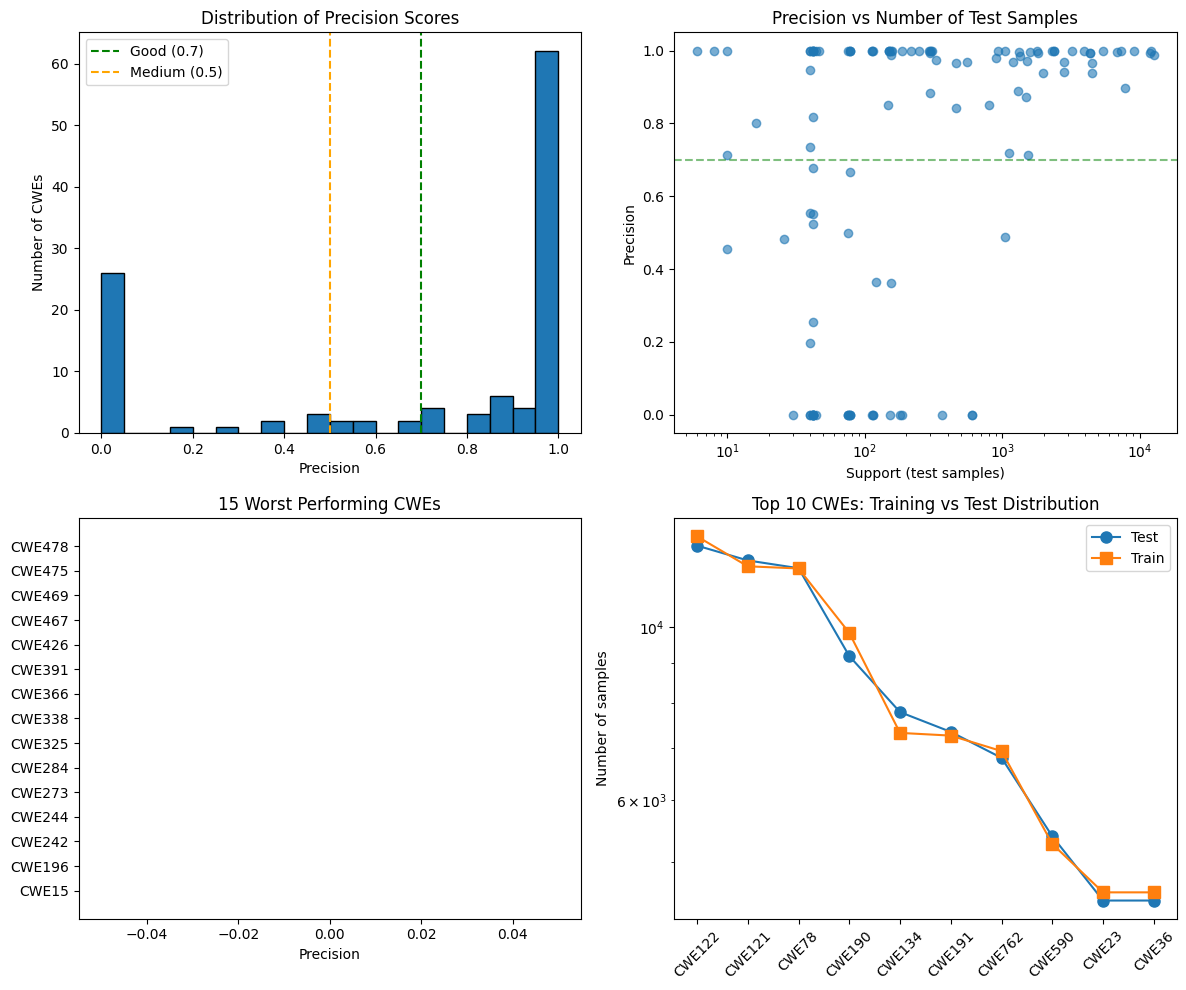


✅ Analysis complete! Check 'my_analysis.png' for visualizations.


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your classification report
df = pd.read_csv('classification_report_updated.csv')

# Basic info about the data
print("Dataset Info:")
print(f"Total CWE classes: {len(df)}")
print(f"Total test samples: {df['support'].sum()}")
print()

# 1. Find problematic CWEs (low precision)
print("="*50)
print("PROBLEMATIC CWEs (Precision < 0.7)")
print("="*50)

problematic = df[df['precision'] < 0.7].sort_values('precision')
for idx, row in problematic.iterrows():
    status = "CRITICAL" if row['precision'] < 0.3 else "WARNING" if row['precision'] < 0.5 else "MODERATE"
    print(f"{row['label']}: precision={row['precision']:.3f}, recall={row['recall']:.3f}, support={int(row['support'])} [{status}]")

print(f"\nTotal problematic CWEs: {len(problematic)}")

# 2. Zero precision CWEs (completely missed)
print("\n" + "="*50)
print("CWEs WITH ZERO PRECISION (Model never predicts these correctly)")
print("="*50)
zero_precision = df[df['precision'] == 0].sort_values('support', ascending=False)
for idx, row in zero_precision.iterrows():
    print(f"{row['label']}: support={int(row['support'])} samples in test set")

# 3. Find CWEs with high recall but low precision (over-predicted)
print("\n" + "="*50)
print("OVER-PREDICTED CWEs (High Recall, Low Precision)")
print("="*50)
over_predicted = df[(df['recall'] > 0.8) & (df['precision'] < 0.5)]
for idx, row in over_predicted.iterrows():
    print(f"{row['label']}: recall={row['recall']:.3f}, precision={row['precision']:.3f}")

# 4. Find CWEs with high precision but low recall (under-predicted)
print("\n" + "="*50)
print("UNDER-PREDICTED CWEs (High Precision, Low Recall)")
print("="*50)
under_predicted = df[(df['precision'] > 0.8) & (df['recall'] < 0.5)]
for idx, row in under_predicted.iterrows():
    print(f"{row['label']}: precision={row['precision']:.3f}, recall={row['recall']:.3f}")

# 5. Group similar CWEs to understand confusion patterns
print("\n" + "="*50)
print("ANALYZING SIMILAR CWE GROUPS")
print("="*50)

# Define CWE families based on common vulnerability types
cwe_families = {
    'Buffer_Errors': ['CWE121', 'CWE122', 'CWE124', 'CWE126', 'CWE127'],
    'Integer_Errors': ['CWE190', 'CWE191', 'CWE194', 'CWE195', 'CWE197'],
    'Path_Traversal': ['CWE22', 'CWE23', 'CWE36'],
    'Resource_Issues': ['CWE404', 'CWE415', 'CWE416', 'CWE672', 'CWE773'],
    'Null_Issues': ['CWE476', 'CWE457', 'CWE690'],
    'Crypto_Issues': ['CWE325', 'CWE327', 'CWE328'],
    'Auth_Issues': ['CWE259', 'CWE321'],
}

# Check performance for each family
for family, cwes in cwe_families.items():
    family_df = df[df['label'].isin(cwes)]
    if len(family_df) > 0:
        print(f"\n{family}:")
        print(f"  Avg Precision: {family_df['precision'].mean():.3f}")
        print(f"  Avg Recall: {family_df['recall'].mean():.3f}")
        
        # Find inconsistencies within family
        precisions = family_df['precision'].values
        if len(precisions) > 1:
            if max(precisions) - min(precisions) > 0.3:
                print(f"  ⚠️ Large variation within family (range: {max(precisions)-min(precisions):.3f})")
                print(f"  Best: {family_df.loc[family_df['precision'].idxmax(), 'label']} ({max(precisions):.3f})")
                print(f"  Worst: {family_df.loc[family_df['precision'].idxmin(), 'label']} ({min(precisions):.3f})")

# 6. Check if there's correlation with training samples
print("\n" + "="*50)
print("TRAINING DATA ANALYSIS")
print("="*50)

# Calculate ratio
df['train_test_ratio'] = df['train_samples'] / df['support']

# Find classes with very few training samples relative to test
low_train = df[df['train_test_ratio'] < 0.5].sort_values('train_test_ratio')
if len(low_train) > 0:
    print("\nClasses with fewer training than test samples:")
    for idx, row in low_train.iterrows():
        print(f"{row['label']}: train={int(row['train_samples'])} vs test={int(row['support'])} (ratio={row['train_test_ratio']:.2f})")

# 7. Summary statistics for report
print("\n" + "="*50)
print("SUMMARY STATISTICS FOR REPORT")
print("="*50)

total = len(df)
print(f"""
Overall Performance:
- Classes with good precision (≥0.7): {len(df[df['precision'] >= 0.7])}/{total} ({len(df[df['precision'] >= 0.7])/total*100:.1f}%)
- Classes with medium precision (0.5-0.7): {len(df[(df['precision'] >= 0.5) & (df['precision'] < 0.7)])}/{total}
- Classes with low precision (<0.5): {len(df[df['precision'] < 0.5])}/{total}
- Classes with zero precision: {len(df[df['precision'] == 0])}/{total}
""")

# 8. Create a simple visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Precision distribution
axes[0,0].hist(df['precision'], bins=20, edgecolor='black')
axes[0,0].set_xlabel('Precision')
axes[0,0].set_ylabel('Number of CWEs')
axes[0,0].set_title('Distribution of Precision Scores')
axes[0,0].axvline(x=0.7, color='g', linestyle='--', label='Good (0.7)')
axes[0,0].axvline(x=0.5, color='orange', linestyle='--', label='Medium (0.5)')
axes[0,0].legend()

# Plot 2: Precision vs Support
axes[0,1].scatter(df['support'], df['precision'], alpha=0.6)
axes[0,1].set_xlabel('Support (test samples)')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision vs Number of Test Samples')
axes[0,1].set_xscale('log')
axes[0,1].axhline(y=0.7, color='g', linestyle='--', alpha=0.5)

# Plot 3: Worst performers
worst = df.nsmallest(15, 'precision')
axes[1,0].barh(range(len(worst)), worst['precision'].values)
axes[1,0].set_yticks(range(len(worst)))
axes[1,0].set_yticklabels(worst['label'].values)
axes[1,0].set_xlabel('Precision')
axes[1,0].set_title('15 Worst Performing CWEs')

# Plot 4: Training vs Test
top_cwes = df.nlargest(10, 'support')
x = range(len(top_cwes))
axes[1,1].plot(x, top_cwes['support'].values, 'o-', label='Test', markersize=8)
axes[1,1].plot(x, top_cwes['train_samples'].values, 's-', label='Train', markersize=8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(top_cwes['label'].values, rotation=45)
axes[1,1].set_ylabel('Number of samples')
axes[1,1].set_title('Top 10 CWEs: Training vs Test Distribution')
axes[1,1].legend()
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.savefig('my_analysis.png', dpi=150)
plt.show()

print("\n✅ Analysis complete! Check 'my_analysis.png' for visualizations.")